# `customer_demographics.py`

Phase 3 — Dashboard A: doanh thu/thói quen theo tuổi & vùng (chart 15-21), RFM segmentation, cohort retention, RFM×region, churn risk rule-based + logistic regression thủ công (numpy), export 3 file data trung gian. Notebook chạy đúng code gốc, chart hiện inline.

In [1]:
%matplotlib inline
import os
os.chdir(r"/Users/lhoanghai_/Downloads/Dự án datathon2026")
__file__ = r"/Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase3_dashboard/customer_demographics.py"  # notebook không có __file__ mặc định -> gán thủ công để mọi Path(__file__)... trong code gốc resolve đúng thư mục như khi chạy .py


## Thiết lập / import

In [2]:
# Doanh thu + thói quen khách hàng theo khu vực (region) và độ tuổi (age_group)
# Kết hợp order_items + orders + products + customers + geography.
# Công thức revenue = gross (qty*unit_price, tất cả trạng thái đơn) — khớp sales.csv
# 0.000% sai lệch, đã xác nhận ở phase0_qc/phase0_data_check.py + phase2_diagnostic/revenue_diagnostic.py.
# Output: EDA_Insight/output/phase3/15..28_*.png
# Chạy: python EDA_Insight/phase3_dashboard/customer_demographics.py (sau khi activate .venv)

import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use("Agg")  # bỏ trong notebook để %matplotlib inline hiển thị chart
import matplotlib.pyplot as plt
from pathlib import Path

HERE = Path(__file__).resolve().parent           # EDA_Insight/phase3_dashboard/
DATA = HERE.parent.parent / "data"                # dữ liệu gốc: <project root>/data
OUT = HERE.parent / "output" / "phase3"           # chart: EDA_Insight/output/phase3/
OUT.mkdir(parents=True, exist_ok=True)
EXPORT = HERE / "data"                            # data trung gian Phase 3
EXPORT.mkdir(exist_ok=True)

C_REV, C_COGS, C_GRAY, C_ACCENT = "#A32D2D", "#185FA5", "#888780", "#534AB7"
PALETTE = ["#185FA5", "#A32D2D", "#3B6D11", "#BA7517", "#534AB7", "#993556"]
AGE_ORDER = ["18-24", "25-34", "35-44", "45-54", "55+"]

plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "grid.linestyle": ":"})

print("Đang load & join dữ liệu...")
orders = pd.read_csv(DATA / "orders.csv", parse_dates=["order_date"])
items = pd.read_csv(DATA / "order_items.csv")
products = pd.read_csv(DATA / "products.csv", usecols=["product_id", "category", "cogs"])
customers = pd.read_csv(DATA / "customers.csv",
                        usecols=["customer_id", "age_group", "gender", "signup_date"])
geography = pd.read_csv(DATA / "geography.csv", usecols=["zip", "region"])

li = (items
      .merge(orders, on="order_id", how="left")
      .merge(products, on="product_id", how="left")
      .merge(customers, on="customer_id", how="left")
      .merge(geography, on="zip", how="left"))

li["line_revenue"] = li["quantity"] * li["unit_price"]
li["year"] = li["order_date"].dt.year
li = li[li["year"].between(2013, 2022)].copy()
li["age_group"] = pd.Categorical(li["age_group"], categories=AGE_ORDER, ordered=True)

print(f"{len(li):,} dòng sau join | {li['customer_id'].nunique():,} khách "
      f"| age_group null: {li['age_group'].isna().sum()}\n")

Đang load & join dữ liệu...


/var/folders/t9/tstf90y13wd9p_7gc7pf9htr0000gp/T/ipykernel_73360/3050407628.py:32: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  items = pd.read_csv(DATA / "order_items.csv")


677,662 dòng sau join | 89,063 khách | age_group null: 0



## 15. REVENUE THEO ĐỘ TUỔI QUA CÁC NĂM

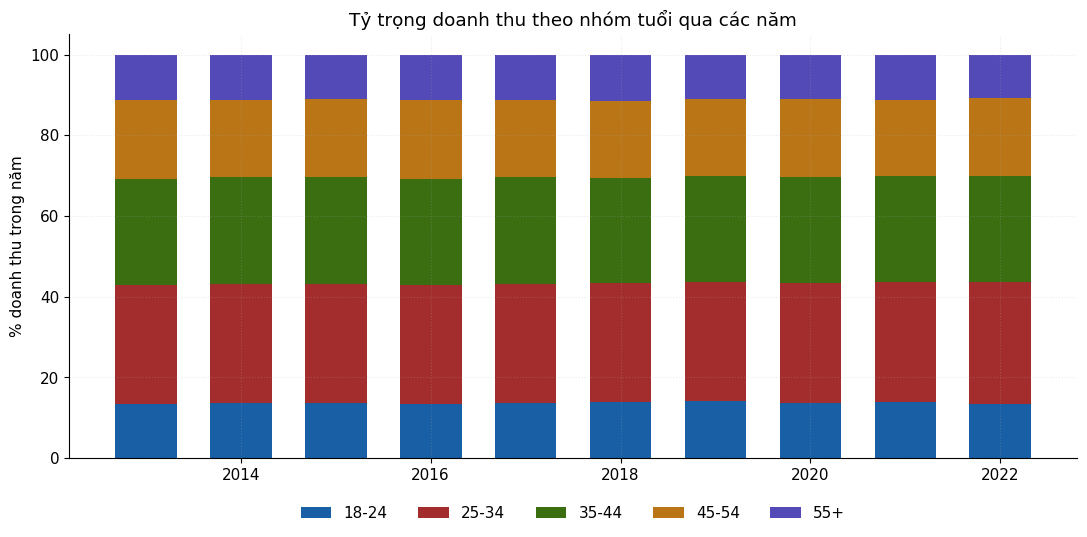

=== 15. Tỷ trọng theo tuổi ===
  2013: {'18-24': 13.3, '25-34': 29.6, '35-44': 26.3, '45-54': 19.4, '55+': 11.4}
  2022: {'18-24': 13.5, '25-34': 30.1, '35-44': 26.4, '45-54': 19.1, '55+': 10.9}



In [3]:
age_yr = li.groupby(["year", "age_group"], observed=True)["line_revenue"].sum().unstack()
age_share = age_yr.div(age_yr.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5.5))
bottom = np.zeros(len(age_share))
for i, ag in enumerate(AGE_ORDER):
    ax.bar(age_share.index, age_share[ag], bottom=bottom, label=ag,
           color=PALETTE[i % len(PALETTE)], width=0.65)
    bottom += age_share[ag].values
ax.set_ylabel("% doanh thu trong năm")
ax.set_title("Tỷ trọng doanh thu theo nhóm tuổi qua các năm")
ax.legend(frameon=False, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.08))
fig.tight_layout(); fig.savefig(OUT / "15_age_share.png", dpi=110); plt.show(); plt.close(fig)

print("=== 15. Tỷ trọng theo tuổi ===")
print(f"  2013: {age_share.loc[2013].round(1).to_dict()}")
print(f"  2022: {age_share.loc[2022].round(1).to_dict()}\n")

**Phân tích chart 15 — Tỷ trọng doanh thu theo độ tuổi**

1. **Thể hiện gì:** tỷ trọng % doanh thu theo nhóm tuổi (18-24, 25-34, 35-44, 45-54, 55+) qua các năm.
2. **Insight:** 2022: 25-34 chiếm nhiều nhất (30.1%), 55+ ít nhất (10.9%) — nhưng đây đơn thuần vì SỐ KHÁCH mỗi nhóm khác nhau (25-34 đông nhất, 26,802 khách), không phải vì nhóm đó chi tiêu khác nhóm khác (AOV mọi nhóm tuổi gần như bằng nhau 25.42-25.59 nghìn VND).
3. **Lưu ý:** đọc riêng chart tỷ trọng doanh thu theo tuổi RẤT dễ nhầm là "tuổi ảnh hưởng hành vi mua" — thực tế chênh lệch lớn nhất giữa các nhóm tuổi trên MỌI chỉ số hành vi (AOV, tần suất, % Streetwear) đều dưới ~4%; `age_group` không mang tín hiệu hành vi trong dữ liệu này.


## 16. HEATMAP REVENUE: ĐỘ TUỔI x KHU VỰC (toàn kỳ 2013-2022)

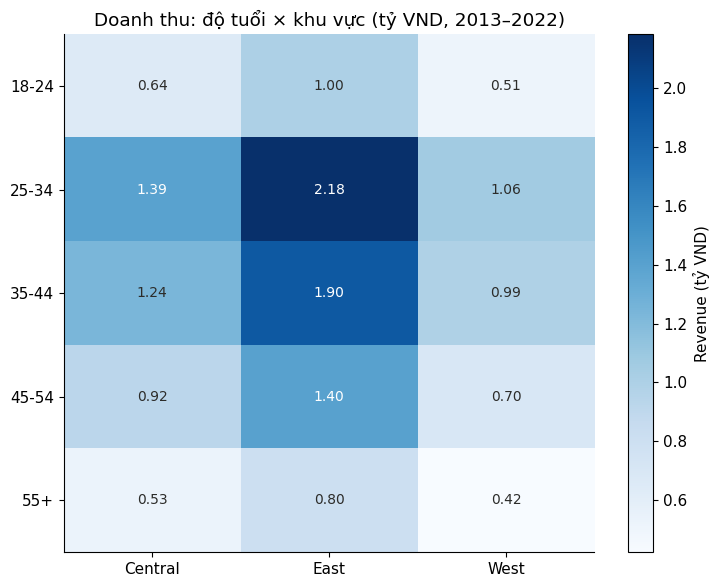

=== 16. Độ tuổi x khu vực (tỷ VND) ===
region     Central  East  West
age_group                     
18-24         0.64  1.00  0.51
25-34         1.39  2.18  1.06
35-44         1.24  1.90  0.99
45-54         0.92  1.40  0.70
55+           0.53  0.80  0.42 



In [4]:
cross = li.pivot_table(index="age_group", columns="region", values="line_revenue",
                       aggfunc="sum", observed=True).reindex(AGE_ORDER) / 1e9

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(cross.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(cross.columns)), cross.columns)
ax.set_yticks(range(len(cross.index)), cross.index)
for i in range(cross.shape[0]):
    for j in range(cross.shape[1]):
        v = cross.values[i, j]
        color = "white" if v > cross.values.max() * 0.6 else "#2c2c2a"
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", color=color, fontsize=10)
ax.grid(False)
fig.colorbar(im, label="Revenue (tỷ VND)")
ax.set_title("Doanh thu: độ tuổi × khu vực (tỷ VND, 2013–2022)")
fig.tight_layout(); fig.savefig(OUT / "16_age_region_heatmap.png", dpi=110); plt.show(); plt.close(fig)

print("=== 16. Độ tuổi x khu vực (tỷ VND) ===")
print(cross.round(2).to_string(), "\n")

**Phân tích chart 16 — Heatmap doanh thu: độ tuổi × khu vực**

1. **Thể hiện gì:** heatmap doanh thu (tỷ VND) theo độ tuổi (hàng) × khu vực (cột), toàn kỳ 2013-2022.
2. **Insight:** dùng để kiểm tra chéo age×region xem có lệch cơ cấu tuổi giữa các vùng không — kết quả: chênh lệch per-capita giữa các vùng (West cao hơn Central 62%) ĐÚNG ở mọi nhóm tuổi, không phải do 1 vùng có cơ cấu tuổi khác biệt kéo lệch số liệu.
3. **Lưu ý:** đây là doanh thu TUYỆT ĐỐI (tỷ VND) theo ô — ô nào đậm nhất chủ yếu phản ánh QUY MÔ dân số (nhóm tuổi đông + vùng đông khách), không phản ánh "chất lượng" khách; nên đọc cùng bảng per-capita (chart 21) để tránh Simpson's paradox.


## 17. AOV THEO ĐỘ TUỔI — "thói quen" chi tiêu mỗi đơn

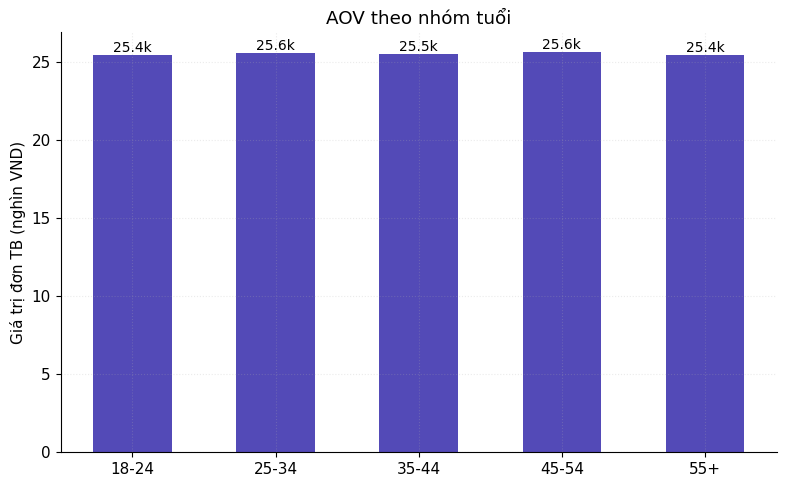

=== 17. AOV theo tuổi (nghìn VND) ===
  {'18-24': 25.42, '25-34': 25.56, '35-44': 25.5, '45-54': 25.59, '55+': 25.42}



In [5]:
order_val = li.groupby(["order_id", "age_group"], observed=True)["line_revenue"].sum().reset_index()
aov_age = order_val.groupby("age_group", observed=True)["line_revenue"].mean().reindex(AGE_ORDER)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(aov_age.index, aov_age.values / 1e3, color=C_ACCENT, width=0.55)
for i, v in enumerate(aov_age.values / 1e3):
    ax.text(i, v, f"{v:.1f}k", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Giá trị đơn TB (nghìn VND)")
ax.set_title("AOV theo nhóm tuổi")
fig.tight_layout(); fig.savefig(OUT / "17_aov_by_age.png", dpi=110); plt.show(); plt.close(fig)

print("=== 17. AOV theo tuổi (nghìn VND) ===")
print(f"  {(aov_age/1e3).round(2).to_dict()}\n")

**Phân tích chart 17 — AOV theo độ tuổi**

1. **Thể hiện gì:** AOV (giá trị đơn trung bình, nghìn VND) theo nhóm tuổi.
2. **Insight:** gần như bằng nhau ở mọi nhóm (25.42-25.59 nghìn VND, chênh lệch nhóm cao nhất/thấp nhất dưới 1%).
3. **Lưu ý:** khác biệt quá nhỏ để có ý nghĩa thực tế (không phải do 1 nhóm chi tiêu khác biệt) — không dùng `age_group` làm biến phân khúc AOV cho chiến dịch giá/pricing.


## 18. TẦN SUẤT MUA (đơn/khách) THEO ĐỘ TUỔI

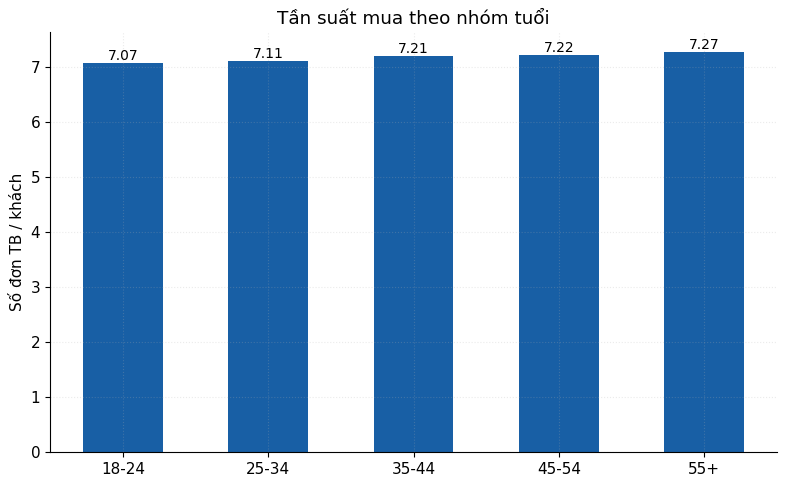

=== 18. Tần suất mua theo tuổi ===
  đơn/khách: {'18-24': 7.07, '25-34': 7.11, '35-44': 7.21, '45-54': 7.22, '55+': 7.27}
  số khách/nhóm: {'18-24': 12599, '25-34': 26802, '35-44': 23642, '45-54': 17193, '55+': 10010}



In [6]:
cust_age = customers.set_index("customer_id")["age_group"]
orders_per_cust = orders.groupby("customer_id").size().rename("n_orders")
freq = orders_per_cust.to_frame().join(cust_age).dropna()
freq_age = freq.groupby("age_group", observed=True)["n_orders"].mean().reindex(AGE_ORDER)
n_cust_age = freq.groupby("age_group", observed=True).size().reindex(AGE_ORDER)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(freq_age.index, freq_age.values, color=C_COGS, width=0.55)
for i, v in enumerate(freq_age.values):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Số đơn TB / khách")
ax.set_title("Tần suất mua theo nhóm tuổi")
fig.tight_layout(); fig.savefig(OUT / "18_order_freq_by_age.png", dpi=110); plt.show(); plt.close(fig)

print("=== 18. Tần suất mua theo tuổi ===")
print(f"  đơn/khách: {freq_age.round(2).to_dict()}")
print(f"  số khách/nhóm: {n_cust_age.to_dict()}\n")

**Phân tích chart 18 — Tần suất mua theo độ tuổi**

1. **Thể hiện gì:** tần suất mua (đơn/khách) theo nhóm tuổi.
2. **Insight:** dao động rất hẹp 7.07-7.27 đơn/khách giữa các nhóm — nhóm 55+ nhỉnh nhất (7.27) nhưng chênh với nhóm thấp nhất (18-24, 7.07) chỉ ~2.8%.
3. **Lưu ý:** chênh lệch nhỏ này nằm trong biên độ nhiễu tự nhiên (không có kiểm định thống kê chính thức đi kèm) — không coi 55+ là nhóm "trung thành hơn" chỉ dựa vào chênh lệch 2-3% này.


## 19. CATEGORY ƯA THÍCH THEO ĐỘ TUỔI (tỷ trọng trong từng nhóm tuổi)

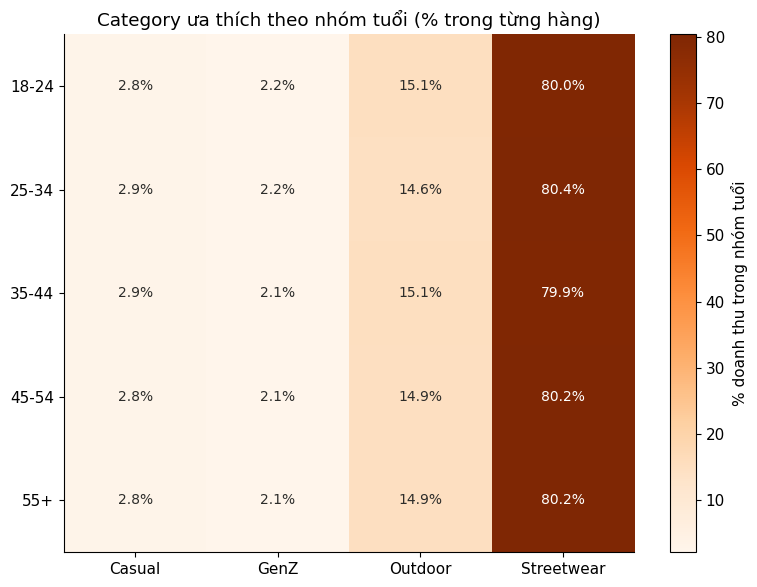

=== 19. Category theo tuổi (% mỗi hàng) ===
category   Casual  GenZ  Outdoor  Streetwear
age_group                                   
18-24         2.8   2.2     15.1        80.0
25-34         2.9   2.2     14.6        80.4
35-44         2.9   2.1     15.1        79.9
45-54         2.8   2.1     14.9        80.2
55+           2.8   2.1     14.9        80.2 



In [7]:
cat_age = li.pivot_table(index="age_group", columns="category", values="line_revenue",
                         aggfunc="sum", observed=True).reindex(AGE_ORDER)
cat_age_share = cat_age.div(cat_age.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cat_age_share.values, cmap="Oranges", aspect="auto")
ax.set_xticks(range(len(cat_age_share.columns)), cat_age_share.columns)
ax.set_yticks(range(len(cat_age_share.index)), cat_age_share.index)
for i in range(cat_age_share.shape[0]):
    for j in range(cat_age_share.shape[1]):
        v = cat_age_share.values[i, j]
        color = "white" if v > 50 else "#2c2c2a"
        ax.text(j, i, f"{v:.1f}%", ha="center", va="center", color=color, fontsize=10)
ax.grid(False)
fig.colorbar(im, label="% doanh thu trong nhóm tuổi")
ax.set_title("Category ưa thích theo nhóm tuổi (% trong từng hàng)")
fig.tight_layout(); fig.savefig(OUT / "19_category_by_age.png", dpi=110); plt.show(); plt.close(fig)

print("=== 19. Category theo tuổi (% mỗi hàng) ===")
print(cat_age_share.round(1).to_string(), "\n")

**Phân tích chart 19 — Category ưa thích theo độ tuổi**

1. **Thể hiện gì:** % doanh thu theo category (Casual/GenZ/Outdoor/Streetwear), trong từng nhóm tuổi (mỗi hàng cộng thành 100%).
2. **Insight:** Streetwear chiếm 79.9-80.4% ở MỌI nhóm tuổi — gần như đồng nhất, không có nhóm tuổi nào lệch hẳn về sở thích category.
3. **Lưu ý:** đồng nhất tuyệt đối qua mọi nhóm tuổi (chênh chưa tới 0.5pp) là dấu hiệu dữ liệu mô phỏng gán sở thích category không phụ thuộc tuổi — khác hành vi tiêu dùng thực tế (thường có phân hoá theo tuổi); không suy diễn "tuổi không ảnh hưởng gu thời trang" ra ngoài phạm vi dữ liệu mô phỏng này.


## 20. GIỚI TÍNH — revenue + AOV + tần suất

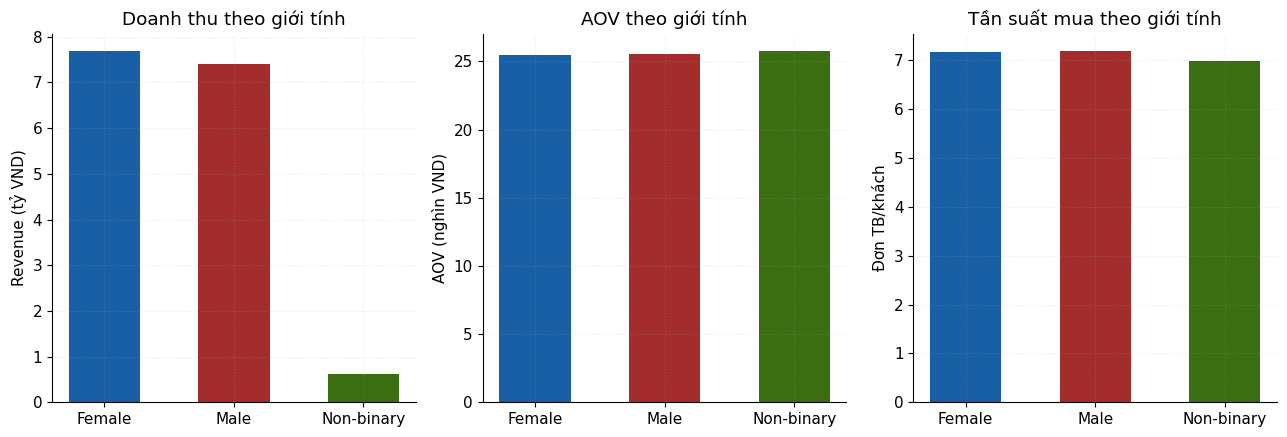

=== 20. Giới tính ===
  Revenue (tỷ): {'Female': 7.68, 'Male': 7.4, 'Non-binary': 0.61}
  AOV (nghìn): {'Female': 25.49, 'Male': 25.52, 'Non-binary': 25.74}
  Tần suất (đơn/khách): {'Female': 7.17, 'Male': 7.18, 'Non-binary': 6.98}



In [8]:
gender_rev = li.groupby("gender")["line_revenue"].sum() / 1e9
order_val_g = li.groupby(["order_id", "gender"])["line_revenue"].sum().reset_index()
aov_gender = order_val_g.groupby("gender")["line_revenue"].mean()
cust_gender = customers.set_index("customer_id")["gender"]
freq_g = orders_per_cust.to_frame().join(cust_gender).dropna().groupby("gender")["n_orders"].mean()

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].bar(gender_rev.index, gender_rev.values, color=PALETTE[:3], width=0.55)
axes[0].set_ylabel("Revenue (tỷ VND)"); axes[0].set_title("Doanh thu theo giới tính")
axes[1].bar(aov_gender.index, aov_gender.values / 1e3, color=PALETTE[:3], width=0.55)
axes[1].set_ylabel("AOV (nghìn VND)"); axes[1].set_title("AOV theo giới tính")
axes[2].bar(freq_g.index, freq_g.values, color=PALETTE[:3], width=0.55)
axes[2].set_ylabel("Đơn TB/khách"); axes[2].set_title("Tần suất mua theo giới tính")
fig.tight_layout(); fig.savefig(OUT / "20_gender_summary.png", dpi=110); plt.show(); plt.close(fig)

print("=== 20. Giới tính ===")
print(f"  Revenue (tỷ): {gender_rev.round(2).to_dict()}")
print(f"  AOV (nghìn): {(aov_gender/1e3).round(2).to_dict()}")
print(f"  Tần suất (đơn/khách): {freq_g.round(2).to_dict()}\n")

**Phân tích chart 20 — Giới tính: revenue + AOV + tần suất**

1. **Thể hiện gì:** revenue, AOV, tần suất theo giới tính (Female/Male/Non-binary).
2. **Insight:** Revenue tỷ lệ đúng theo số khách (Female 59,640 · Male 57,457 · Non-binary 4,833); AOV (25.49/25.52/25.74 nghìn) và tần suất (7.17/7.18/6.98 đơn/khách) gần như bằng nhau giữa 3 nhóm.
3. **Lưu ý:** không có tín hiệu hành vi theo giới tính — không dùng `gender` làm biến phân khúc marketing/feature model, sẽ chỉ thêm nhiễu.


## 21. REVENUE / KHÁCH (per-capita) — tách ảnh hưởng số lượng khỏi hành vi thật Chart 15/16 là TỔNG, dễ đọc nhầm: khu vực ít khách trông "kém" dù mỗi khách ở đó chi nhiều hơn. Đây là chart đối chiếu bắt buộc phải xem cùng.

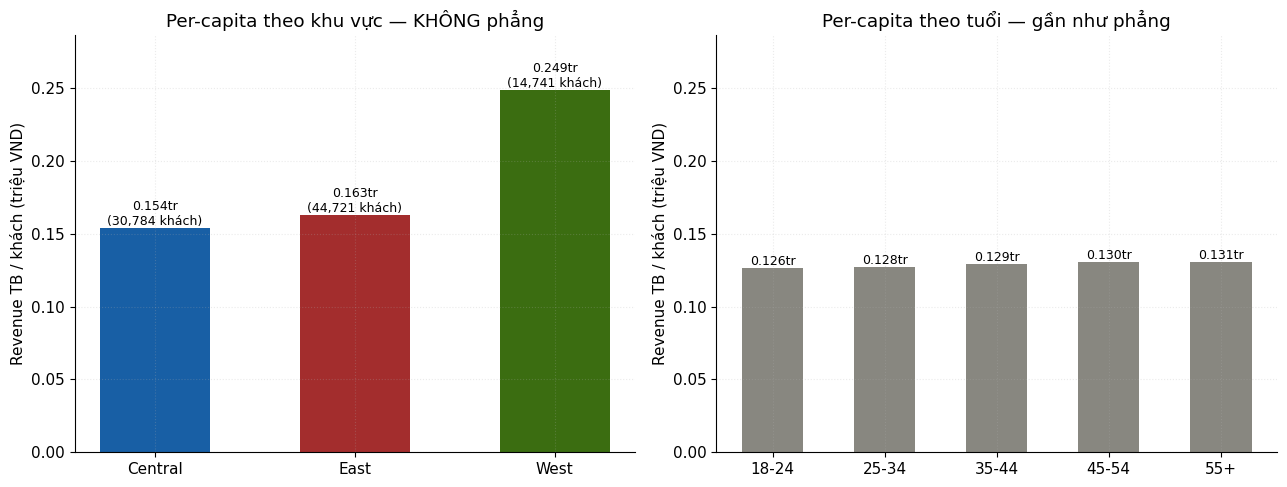

=== 21. Revenue/khách (triệu VND) — per-capita ===
  Theo region: {'Central': 0.1537, 'East': 0.163, 'West': 0.2489}
  Theo tuổi  : {'18-24': 0.1262, '25-34': 0.1275, '35-44': 0.1293, '45-54': 0.1303, '55+': 0.1305}
  West cao hơn Central: 62.0%

Đã lưu 7 chart (15-21) vào /Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/output/phase3


In [9]:
cust_rev = li.groupby("customer_id")["line_revenue"].sum().rename("total_rev")
cust_dim = customers.set_index("customer_id")[["age_group", "gender"]].join(
    orders[["customer_id", "zip"]].drop_duplicates("customer_id").set_index("customer_id")
).join(geography.set_index("zip")["region"], on="zip")
percap = cust_dim.join(cust_rev).fillna({"total_rev": 0})

percap_region = percap.groupby("region")["total_rev"].mean() / 1e6
percap_age = percap.groupby("age_group", observed=True)["total_rev"].mean().reindex(AGE_ORDER) / 1e6
n_region = percap["region"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bars0 = axes[0].bar(percap_region.index, percap_region.values, color=PALETTE[:3], width=0.55)
for i, (reg, v) in enumerate(percap_region.items()):
    axes[0].text(i, v, f"{v:.3f}tr\n({n_region[reg]:,} khách)", ha="center", va="bottom", fontsize=9)
axes[0].set_ylabel("Revenue TB / khách (triệu VND)")
axes[0].set_title("Per-capita theo khu vực — KHÔNG phẳng")

axes[1].bar(percap_age.index, percap_age.values, color=C_GRAY, width=0.55)
for i, v in enumerate(percap_age.values):
    axes[1].text(i, v, f"{v:.3f}tr", ha="center", va="bottom", fontsize=9)
axes[1].set_ylabel("Revenue TB / khách (triệu VND)")
axes[1].set_title("Per-capita theo tuổi — gần như phẳng")
axes[1].set_ylim(0, percap_region.max() * 1.15)
axes[0].set_ylim(0, percap_region.max() * 1.15)
fig.tight_layout(); fig.savefig(OUT / "21_revenue_per_customer.png", dpi=110); plt.show(); plt.close(fig)

print("=== 21. Revenue/khách (triệu VND) — per-capita ===")
print(f"  Theo region: {percap_region.round(4).to_dict()}")
print(f"  Theo tuổi  : {percap_age.round(4).to_dict()}")
print(f"  West cao hơn Central: {(percap_region['West']/percap_region['Central']-1)*100:.1f}%\n")

print(f"Đã lưu 7 chart (15-21) vào {OUT}")

**Phân tích chart 21 — Revenue/khách (per-capita) theo vùng**

1. **Thể hiện gì:** Revenue/khách (per-capita, triệu VND) theo vùng — tách ảnh hưởng số lượng khách khỏi hành vi thật.
2. **Insight:** West **0.249** triệu/khách (cao nhất) so với Central 0.154 và East 0.163 — West cao hơn Central **62%**, cao hơn East 53%, dù West có SỐ KHÁCH ít nhất (14,741 so East 44,721). Đây là **Simpson's paradox** kinh điển: nhìn Revenue tổng tưởng West kém nhất, nhìn per-capita thì ngược lại.
3. **Lưu ý:** bất kỳ chart "theo vùng" nào khác (VD chart 8 ở `revenue_diagnostic`) nếu chỉ nhìn TỔNG doanh thu sẽ dễ hiểu lầm y hệt — luôn đối chiếu với per-capita trước khi kết luận vùng nào "quan trọng" hơn.


## RFM SEGMENTATION — Recency / Frequency / Monetary Recency  = số ngày từ đơn KHÔNG-cancelled gần nhất tới ngày cuối dữ liệu Frequency = số đơn không-cancelled Monetary  = tổng payment_value (net thực thu, QC khớp 100% net/đơn — I1) trên đơn không-cancelled (loại cancelled, giữ delivered/returned/shipped/paid/created)

Đang tính RFM...


  Khách có >=1 đơn (mọi trạng thái): 90,246
  Khách có >=1 đơn KHÔNG-cancelled (= mẫu RFM): 88,123 (chênh 2,123 khách chỉ toàn đơn cancelled -> loại khỏi RFM)



=== 22. RFM segment summary ===
                 n_customers  total_monetary  avg_recency  avg_frequency  pct_customers  pct_monetary
segment                                                                                              
Champions              22575    8.949596e+09       274.23          15.88          25.62         62.88
Loyal Customers        16974    2.884125e+09       787.01           7.02          19.26         20.26
At Risk                 7989    6.461639e+08      2009.51           3.90           9.07          4.54
Can't Lose Them         2251    4.920698e+08      1782.76           8.61           2.55          3.46
Lost                   21682    4.587557e+08      2562.65           1.26          24.60          3.22
Hibernating             3327    2.696038e+08      2398.74           1.60           3.78          1.89
Promising               5375    2.054179e+08      1105.38           1.48           6.10          1.44
New Customers           4865    2.033228e+08      

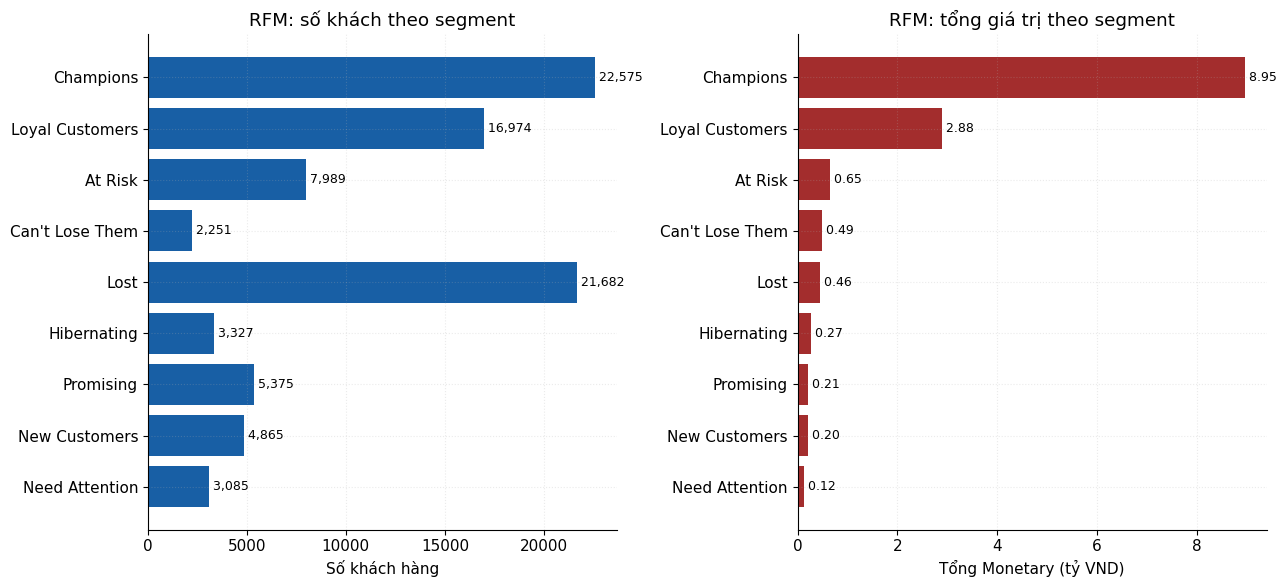

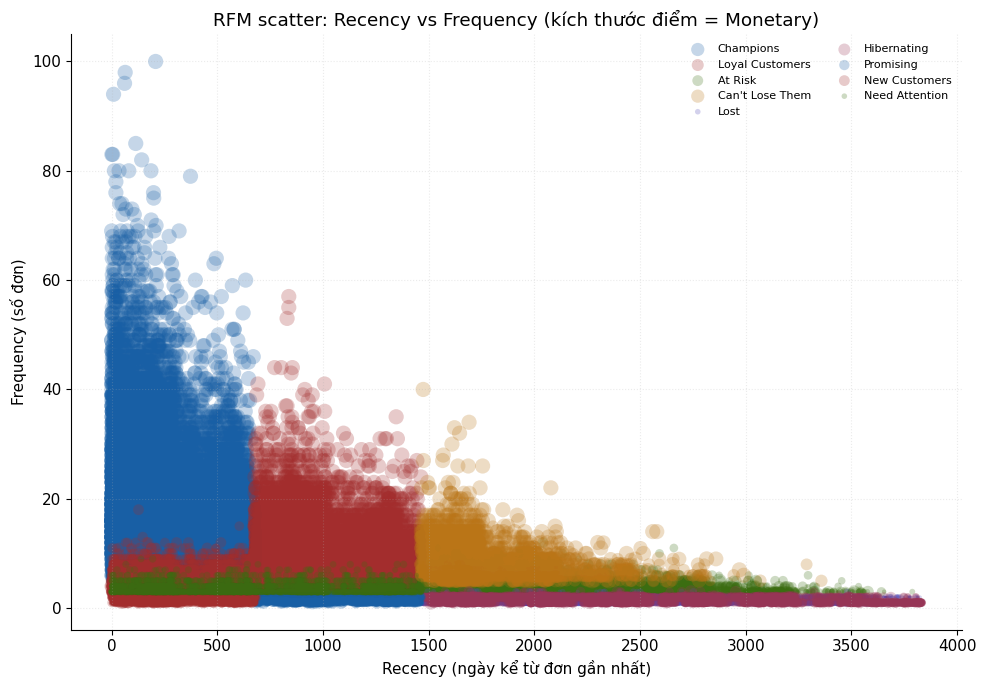

In [10]:
print("Đang tính RFM...")
payments = pd.read_csv(DATA / "payments.csv", usecols=["order_id", "payment_value"])
customers_zip = pd.read_csv(DATA / "customers.csv", usecols=["customer_id", "zip"])

SNAPSHOT_DATE = orders["order_date"].max()          # 2022-12-31 — ngày cuối dữ liệu
SHOP_OPEN = pd.Timestamp("2012-07-04")               # ngày mở bán thực tế (W8)

non_cancel = orders[orders["order_status"] != "cancelled"].merge(
    payments, on="order_id", how="left")

rfm = non_cancel.groupby("customer_id").agg(
    last_order=("order_date", "max"),
    frequency=("order_id", "nunique"),
    monetary=("payment_value", "sum"),
).reset_index()
rfm["recency_days"] = (SNAPSHOT_DATE - rfm["last_order"]).dt.days

n_any_order = orders["customer_id"].nunique()
n_noncancel_order = rfm["customer_id"].nunique()
print(f"  Khách có >=1 đơn (mọi trạng thái): {n_any_order:,}")
print(f"  Khách có >=1 đơn KHÔNG-cancelled (= mẫu RFM): {n_noncancel_order:,} "
      f"(chênh {n_any_order - n_noncancel_order:,} khách chỉ toàn đơn cancelled -> loại khỏi RFM)\n")


def qscore(s, labels):
    ranks = s.rank(method="first")
    return pd.qcut(ranks, 5, labels=labels).astype(int)


rfm["R_score"] = qscore(rfm["recency_days"], [5, 4, 3, 2, 1])   # recency nhỏ = tốt = điểm cao
rfm["F_score"] = qscore(rfm["frequency"], [1, 2, 3, 4, 5])
rfm["M_score"] = qscore(rfm["monetary"], [1, 2, 3, 4, 5])


def rfm_segment(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    if r >= 3 and f >= 3 and m >= 3:
        return "Loyal Customers"
    if r >= 4 and f <= 2:
        return "New Customers"
    if r == 3 and f <= 2:
        return "Promising"
    if r <= 2 and f >= 4 and m >= 4:
        return "Can't Lose Them"
    if r <= 2 and f >= 3:
        return "At Risk"
    if r <= 2 and f <= 2 and m >= 3:
        return "Hibernating"
    if r <= 2 and f <= 2:
        return "Lost"
    return "Need Attention"


rfm["segment"] = rfm.apply(rfm_segment, axis=1)

seg_summary = (rfm.groupby("segment")
               .agg(n_customers=("customer_id", "count"),
                    total_monetary=("monetary", "sum"),
                    avg_recency=("recency_days", "mean"),
                    avg_frequency=("frequency", "mean"))
               .sort_values("total_monetary", ascending=False))
seg_summary["pct_customers"] = seg_summary["n_customers"] / seg_summary["n_customers"].sum() * 100
seg_summary["pct_monetary"] = seg_summary["total_monetary"] / seg_summary["total_monetary"].sum() * 100

print("=== 22. RFM segment summary ===")
print(seg_summary.round(2).to_string(), "\n")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
order_idx = seg_summary.index
axes[0].barh(order_idx, seg_summary["n_customers"], color=PALETTE[0])
axes[0].invert_yaxis()
axes[0].set_xlabel("Số khách hàng")
axes[0].set_title("RFM: số khách theo segment")
for i, v in enumerate(seg_summary["n_customers"]):
    axes[0].text(v, i, f" {v:,}", va="center", fontsize=9)

axes[1].barh(order_idx, seg_summary["total_monetary"] / 1e9, color=PALETTE[1])
axes[1].invert_yaxis()
axes[1].set_xlabel("Tổng Monetary (tỷ VND)")
axes[1].set_title("RFM: tổng giá trị theo segment")
for i, v in enumerate(seg_summary["total_monetary"] / 1e9):
    axes[1].text(v, i, f" {v:.2f}", va="center", fontsize=9)
fig.tight_layout(); fig.savefig(OUT / "22_rfm_segment_summary.png", dpi=110); plt.show(); plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 7))
for i, seg in enumerate(order_idx):
    sub = rfm[rfm["segment"] == seg]
    ax.scatter(sub["recency_days"], sub["frequency"],
               s=np.clip(sub["monetary"] / 2000, 3, 120),
               alpha=0.25, color=PALETTE[i % len(PALETTE)], label=seg, edgecolors="none")
ax.set_xlabel("Recency (ngày kể từ đơn gần nhất)")
ax.set_ylabel("Frequency (số đơn)")
ax.set_title("RFM scatter: Recency vs Frequency (kích thước điểm = Monetary)")
ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper right")
fig.tight_layout(); fig.savefig(OUT / "23_rfm_scatter.png", dpi=110); plt.show(); plt.close(fig)

**Phân tích chart 22 (trên) + 23 (dưới) — RFM segment summary + RFM scatter**

1. **Thể hiện gì:** chart trên (22) là số khách/tổng Monetary theo 9 segment (Champions, Loyal, Lost, At Risk, Can't Lose Them, Hibernating, Promising, New Customers, Need Attention). Chart dưới (23) là scatter — mỗi điểm 1 khách, trục X = Recency, trục Y = Frequency, kích thước điểm = Monetary.
2. **Insight:** Champions chỉ 25.6% số khách (22,575) nhưng chiếm **62.9%** tổng Monetary (8.95/14.23 tỷ VND) — Pareto rõ rệt. Lost chiếm 24.6% số khách nhưng chỉ 3.2% giá trị (Frequency TB chỉ 1.26 đơn — chưa từng thực sự trung thành). Can't Lose Them (2,251 khách) tuy nhỏ nhưng Monetary/khách 218,601 VND — cao thứ 2 toàn bộ segment.
3. **Lưu ý:** điểm R/F/M dùng NGŨ PHÂN VỊ tương đối (so khách với nhau), không phải ngưỡng tuyệt đối — 1 khách "Lost" theo RFM chỉ có nghĩa thuộc 20% tệ nhất trong MẪU NÀY, không chắc đã thực sự "bỏ đi" theo nghĩa tuyệt đối (xem đối chiếu với churn-risk ngưỡng tuyệt đối ở chart 27 — con số khác nhau tới 3 lần).


## COHORT RETENTION — cohort theo THÁNG signup_date 238 khách signup trước ngày mở bán (2012-07-04, W8) TÁCH riêng khỏi cohort chính (không tính vào heatmap/curve), báo cáo riêng bên dưới.

Đang tính cohort retention...
  Cohort chính (loại 238 khách pre-launch): 121,692 khách, 126 cohort tháng (2012-07 -> 2022-12)


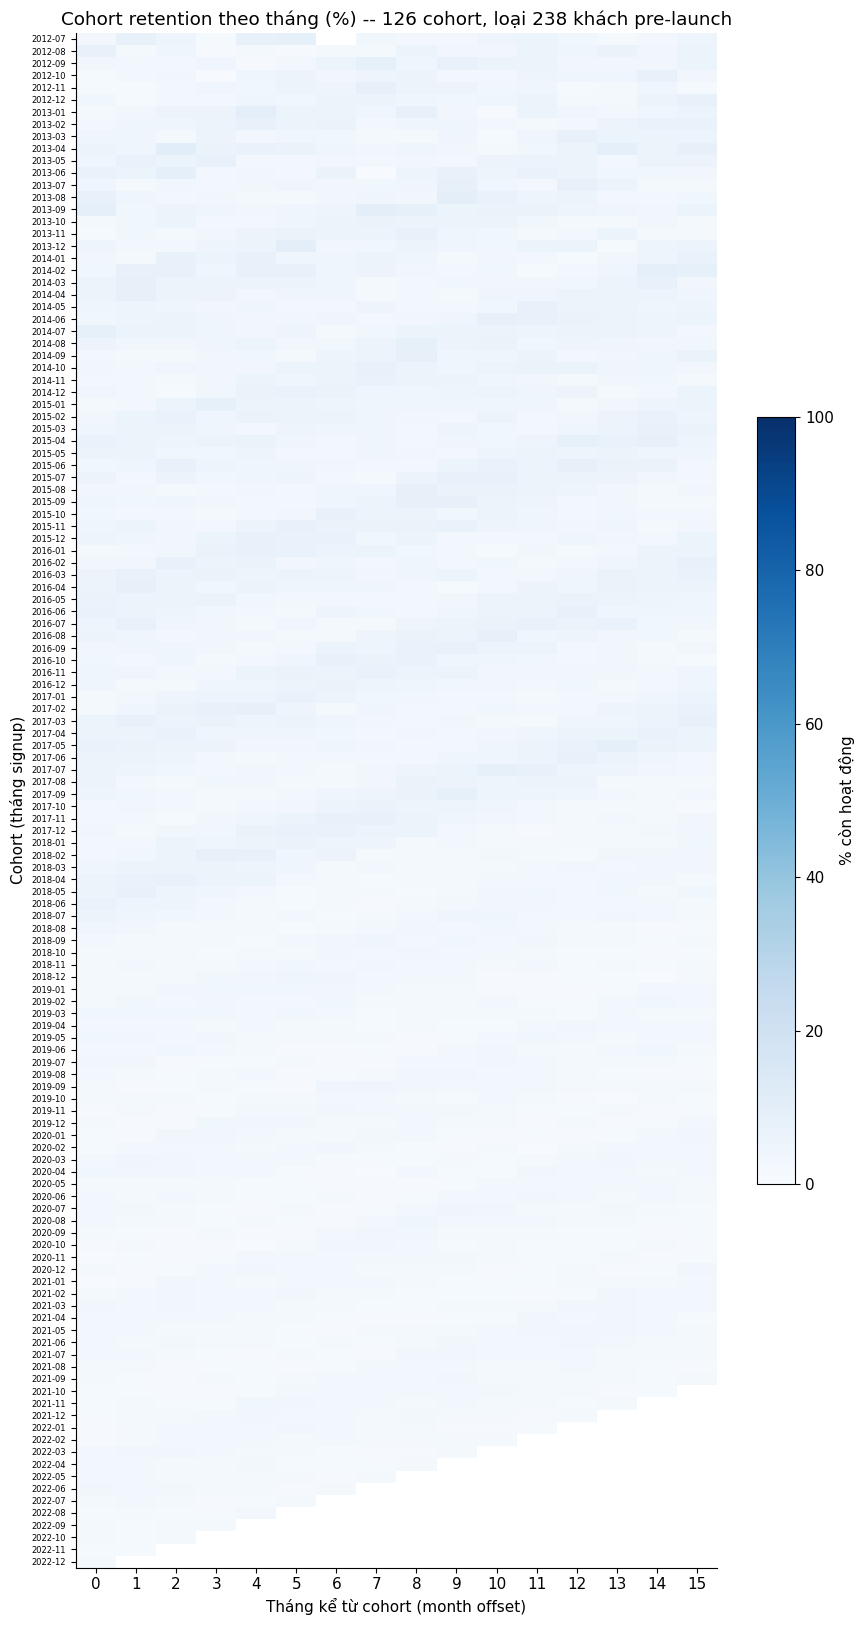

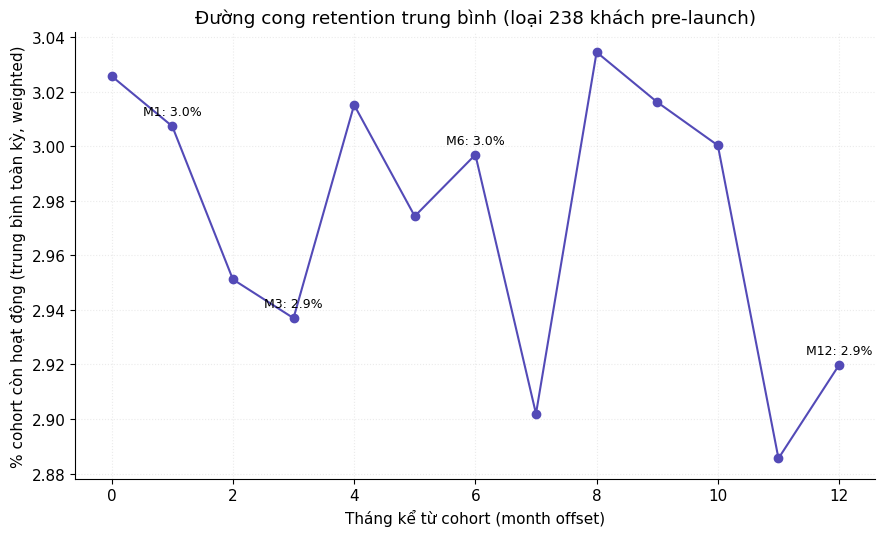

=== 24-25. Cohort retention ===
  Retention mốc (trung bình toàn kỳ): {'M1': 3.0, 'M3': 2.9, 'M6': 3.0, 'M12': 2.9}
  238 khách pre-launch: 171 từng có đơn non-cancelled (71.8%), tổng monetary 28.7 triệu VND, avg frequency 6.68 đơn/khách (so với toàn mẫu RFM: 6.67 đơn/khách)



In [11]:
print("Đang tính cohort retention...")
customers_full = customers.merge(customers_zip, on="customer_id", how="left")
customers_full["signup_date"] = pd.to_datetime(customers_full["signup_date"])
is_pre_launch = customers_full["signup_date"] < SHOP_OPEN
pre_launch = customers_full[is_pre_launch].copy()
cohort_customers = customers_full[~is_pre_launch].copy()
cohort_customers["cohort_month"] = cohort_customers["signup_date"].dt.to_period("M")

orders_nc = non_cancel[["customer_id", "order_date"]].copy()
orders_nc["order_month"] = orders_nc["order_date"].dt.to_period("M")

merged = orders_nc.merge(cohort_customers[["customer_id", "cohort_month"]],
                          on="customer_id", how="inner")
merged["month_offset"] = ((merged["order_month"].dt.year - merged["cohort_month"].dt.year) * 12
                           + (merged["order_month"].dt.month - merged["cohort_month"].dt.month))
merged = merged[merged["month_offset"] >= 0]

cohort_sizes = cohort_customers.groupby("cohort_month")["customer_id"].nunique()
active = merged.groupby(["cohort_month", "month_offset"])["customer_id"].nunique().unstack()
retention_pct = active.divide(cohort_sizes, axis=0) * 100

MAX_OFFSET = 15
retention_pct_clip = retention_pct.reindex(columns=range(0, MAX_OFFSET + 1))

print(f"  Cohort chính (loại {len(pre_launch)} khách pre-launch): {len(cohort_customers):,} khách, "
      f"{cohort_sizes.shape[0]} cohort tháng ({cohort_sizes.index.min()} -> {cohort_sizes.index.max()})")

n_rows = retention_pct_clip.shape[0]
fig, ax = plt.subplots(figsize=(9, max(6, n_rows * 0.13)))
im = ax.imshow(retention_pct_clip.values, cmap="Blues", aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(retention_pct_clip.shape[1]), retention_pct_clip.columns)
ax.set_yticks(range(n_rows), [str(p) for p in retention_pct_clip.index])
ax.tick_params(axis="y", labelsize=6)
ax.set_xlabel("Tháng kể từ cohort (month offset)")
ax.set_ylabel("Cohort (tháng signup)")
ax.set_title(f"Cohort retention theo tháng (%) -- {n_rows} cohort, loại {len(pre_launch)} khách pre-launch")
ax.grid(False)
fig.colorbar(im, label="% còn hoạt động", shrink=0.5)
fig.tight_layout(); fig.savefig(OUT / "24_cohort_retention_heatmap.png", dpi=120); plt.show(); plt.close(fig)

max_month = orders_nc["order_month"].max()
offsets = range(0, 13)
avg_retention = {}
for off in offsets:
    eligible = cohort_sizes.index[cohort_sizes.index + off <= max_month]
    denom = cohort_sizes.loc[eligible].sum()
    if off in active.columns:
        numer = active.reindex(index=eligible, columns=[off]).fillna(0).sum().iloc[0]
    else:
        numer = 0
    avg_retention[off] = numer / denom * 100 if denom > 0 else np.nan
avg_retention = pd.Series(avg_retention)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(avg_retention.index, avg_retention.values, marker="o", color=C_ACCENT)
for m in [1, 3, 6, 12]:
    if m in avg_retention.index:
        ax.annotate(f"M{m}: {avg_retention[m]:.1f}%", (m, avg_retention[m]),
                    textcoords="offset points", xytext=(0, 8), fontsize=9, ha="center")
ax.set_xlabel("Tháng kể từ cohort (month offset)")
ax.set_ylabel("% cohort còn hoạt động (trung bình toàn kỳ, weighted)")
ax.set_title("Đường cong retention trung bình (loại 238 khách pre-launch)")
fig.tight_layout(); fig.savefig(OUT / "25_cohort_retention_curve.png", dpi=110); plt.show(); plt.close(fig)

print("=== 24-25. Cohort retention ===")
milestone = {f"M{k}": round(v, 1) for k, v in avg_retention.items() if k in [1, 3, 6, 12]}
print(f"  Retention mốc (trung bình toàn kỳ): {milestone}")

pre_launch_ids = set(pre_launch["customer_id"])
rfm_pre = rfm[rfm["customer_id"].isin(pre_launch_ids)]
pct_ever_bought = len(rfm_pre) / len(pre_launch) * 100 if len(pre_launch) else np.nan
print(f"  238 khách pre-launch: {len(rfm_pre)} từng có đơn non-cancelled ({pct_ever_bought:.1f}%), "
      f"tổng monetary {rfm_pre['monetary'].sum()/1e6:.1f} triệu VND, "
      f"avg frequency {rfm_pre['frequency'].mean():.2f} đơn/khách "
      f"(so với toàn mẫu RFM: {rfm['frequency'].mean():.2f} đơn/khách)\n")

**Phân tích chart 24 (trên) + 25 (dưới) — Cohort retention heatmap + curve**

1. **Thể hiện gì:** chart trên (24, heatmap) là 126 cohort tháng (hàng) × offset 0-15 tháng kể từ signup (cột), màu = % khách còn active. Chart dưới (25, đường) là đường trung bình retention % theo offset (dễ đọc hơn heatmap 126 hàng).
2. **Insight:** retention trung bình gần như PHẲNG qua mọi offset: M1≈3.0%, M3≈2.9%, M6≈3.0%, M12≈2.9% — KHÔNG có decay theo tuổi cohort như hầu hết mô hình e-commerce thực tế (thường cao ở M1 rồi giảm dần). Khả năng cao nhất: cơ chế sinh dữ liệu mô phỏng gán xác suất mua hàng gần như hằng số theo tháng, không phụ thuộc "tuổi" quan hệ với shop.
3. **Lưu ý:** đây là dữ liệu MÔ PHỎNG — kết luận "không có decay" chỉ đúng cho bộ dữ liệu này, không suy diễn shop thật cũng vậy; heatmap 126 hàng khó đọc trực quan ở kích thước nhỏ (ưu tiên xem chart đường 25), và offset lớn (>12 tháng) có ít cohort đủ điều kiện quan sát hơn (cohort gần cuối kỳ dữ liệu chưa đủ thời gian trôi qua).


## RFM x DEMOGRAPHICS — segment nào tập trung ở vùng nào

=== 26. RFM segment theo region (% khách trong mỗi vùng) ===
region           Central  East  West
segment                             
At Risk              8.0  10.4   7.4
Can't Lose Them      2.1   2.7   3.2
Champions           22.7  24.1  36.1
Hibernating          4.5   3.7   2.5
Lost                27.9  23.4  21.4
Loyal Customers     17.2  21.2  17.7
Need Attention       3.5   3.6   3.1
New Customers        6.8   5.1   4.0
Promising            7.4   5.7   4.6 



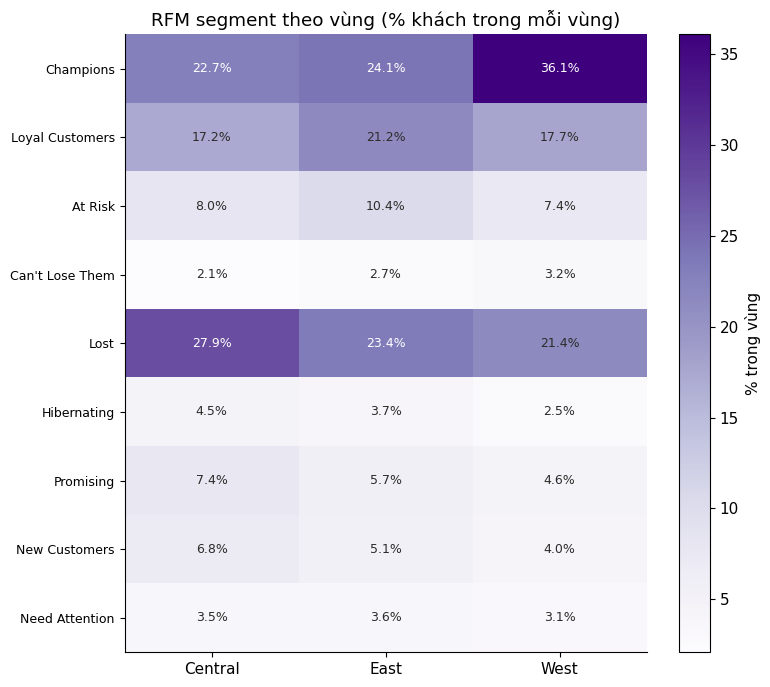

In [12]:
rfm_geo = rfm.merge(customers_zip, on="customer_id", how="left").merge(geography, on="zip", how="left")
seg_region = pd.crosstab(rfm_geo["segment"], rfm_geo["region"])
seg_region_pct = seg_region.div(seg_region.sum(axis=0), axis=1) * 100   # % trong từng vùng

print("=== 26. RFM segment theo region (% khách trong mỗi vùng) ===")
print(seg_region_pct.round(1).to_string(), "\n")

fig, ax = plt.subplots(figsize=(8, 7))
mat = seg_region_pct.reindex(order_idx)
im = ax.imshow(mat.values, cmap="Purples", aspect="auto")
ax.set_xticks(range(mat.shape[1]), mat.columns)
ax.set_yticks(range(mat.shape[0]), mat.index, fontsize=9)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i, j]
        color = "white" if v > np.nanmax(mat.values) * 0.6 else "#2c2c2a"
        ax.text(j, i, f"{v:.1f}%", ha="center", va="center", color=color, fontsize=9)
ax.grid(False)
ax.set_title("RFM segment theo vùng (% khách trong mỗi vùng)")
fig.colorbar(im, label="% trong vùng")
fig.tight_layout(); fig.savefig(OUT / "26_rfm_region_heatmap.png", dpi=110); plt.show(); plt.close(fig)

**Phân tích chart 26 — RFM segment theo vùng**

1. **Thể hiện gì:** heatmap % khách theo RFM segment (hàng) × vùng (cột) — mỗi cột (vùng) cộng thành 100%.
2. **Insight:** West có % Champions cao nhất (**36.1%** vs Central 22.7%, East 24.1%) và % Lost thấp nhất (21.4%) — khớp hoàn toàn với phát hiện per-capita (chart 21): West chi tiêu/khách cao hơn Central 62%. Hai phương pháp độc lập cùng chỉ ra 1 kết luận → tăng độ tin cậy: chất lượng khách West thực sự tốt hơn.
3. **Lưu ý:** vẫn là correlation — dữ liệu không có biến giải thích "tại sao" (marketing spend theo vùng, đối thủ cạnh tranh, thu nhập vùng...) để khẳng định nguyên nhân; West cũng có quy mô khách nhỏ nhất nên % có thể dao động lớn hơn khi thêm/bớt vài trăm khách, không phải bằng chứng thống kê có kiểm định.


## CHURN RISK — rule-based (Recency + xu hướng Frequency 180 ngày gần nhất)

Đang tính churn risk (rule-based)...


=== 27. Churn risk (rule-based) ===
                   n_customers  total_monetary
churn_tier                                    
Da roi bo (>365d)        65071    6.946158e+09
An toan                  10819    3.714954e+09
Rui ro cao               11762    3.291939e+09
Rui ro trung binh          471    2.808041e+08 



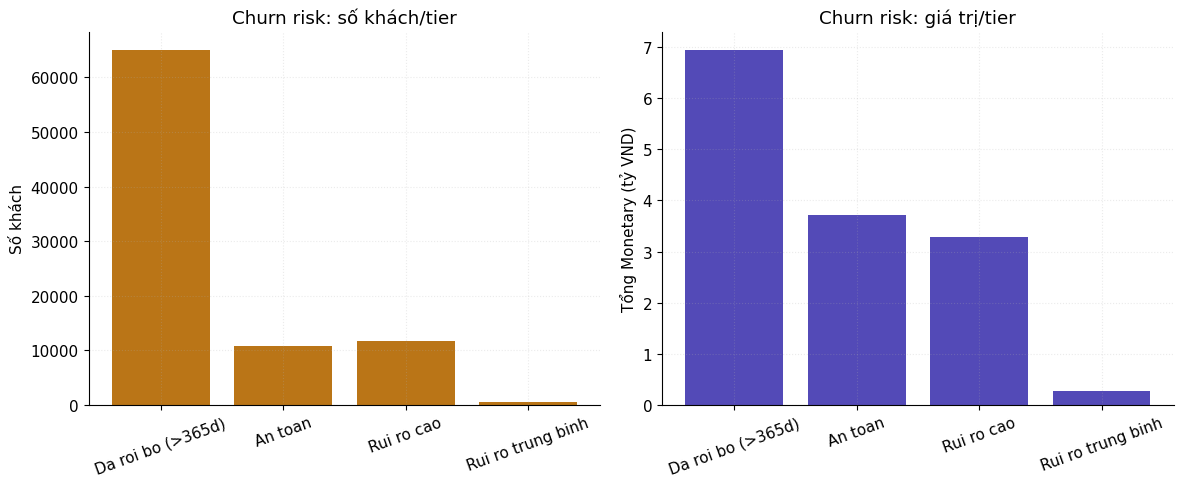

In [13]:
print("Đang tính churn risk (rule-based)...")
freq_recent = non_cancel[non_cancel["order_date"] > SNAPSHOT_DATE - pd.Timedelta(days=180)]
freq_prior = non_cancel[(non_cancel["order_date"] <= SNAPSHOT_DATE - pd.Timedelta(days=180)) &
                         (non_cancel["order_date"] > SNAPSHOT_DATE - pd.Timedelta(days=360))]
f_recent = freq_recent.groupby("customer_id").size().rename("f_recent")
f_prior = freq_prior.groupby("customer_id").size().rename("f_prior")

risk = rfm.set_index("customer_id")[["recency_days", "frequency", "monetary"]].join(f_recent).join(f_prior).fillna(0)
risk["trend"] = risk["f_recent"] - risk["f_prior"]


def churn_tier(row):
    if row["recency_days"] > 365:
        return "Da roi bo (>365d)"
    if row["recency_days"] > 180 and row["trend"] <= 0:
        return "Rui ro cao"
    if row["recency_days"] > 90 and row["trend"] < 0:
        return "Rui ro trung binh"
    return "An toan"


risk["churn_tier"] = risk.apply(churn_tier, axis=1)
risk_summary = (risk.groupby("churn_tier")
                 .agg(n_customers=("recency_days", "count"), total_monetary=("monetary", "sum"))
                 .sort_values("total_monetary", ascending=False))

print("=== 27. Churn risk (rule-based) ===")
print(risk_summary.round(0).to_string(), "\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(risk_summary.index, risk_summary["n_customers"], color=PALETTE[3])
axes[0].set_ylabel("Số khách"); axes[0].set_title("Churn risk: số khách/tier")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(risk_summary.index, risk_summary["total_monetary"] / 1e9, color=PALETTE[4])
axes[1].set_ylabel("Tổng Monetary (tỷ VND)"); axes[1].set_title("Churn risk: giá trị/tier")
axes[1].tick_params(axis="x", rotation=20)
fig.tight_layout(); fig.savefig(OUT / "27_churn_risk_summary.png", dpi=110); plt.show(); plt.close(fig)

**Phân tích chart 27 — Churn risk rule-based summary**

1. **Thể hiện gì:** 2 panel — số khách và tổng Monetary (tỷ VND) theo 4 tier churn-risk rule-based (Đã rời bỏ >365 ngày, Rủi ro cao, Rủi ro trung bình, An toàn).
2. **Insight:** "Đã rời bỏ" (Recency >365 ngày) chiếm **65,071 khách (73.8% mẫu, 6.95 tỷ VND)** — gấp 3 lần con số "Lost" theo RFM (chỉ 21,682 khách, 24.6%). Lý do: RFM dùng ngũ phân vị (luôn ~20-25% tệ nhất bất kể mức độ tệ tuyệt đối), còn churn-risk dùng ngưỡng tuyệt đối 365 ngày nên phản ánh đúng hơn mức độ nghiêm trọng thực tế.
3. **Lưu ý:** bài học quan trọng — không chỉ nhìn RFM segment để đánh giá QUY MÔ vấn đề churn, phải đối chiếu ngưỡng tuyệt đối; ngưỡng 90/180/365 ngày chọn theo kinh nghiệm phổ biến ngành, chưa tối ưu hoá bằng dữ liệu (chưa tìm ngưỡng tối ưu F1/lợi nhuận kỳ vọng).


## LOGISTIC REGRESSION THỦ CÔNG (numpy, không sklearn/scipy — venv không có) Time-split validation: cutoff 2022-06-30, feature tính đến cutoff, label = không mua gì trong 6 tháng sau cutoff (tránh leakage).

Đang huấn luyện logistic regression thủ công (numpy, time-split validation)...


  Tập validate: 87,589 khách có đơn <= 2022-06-30, churn rate thực tế 6 tháng sau = 87.4%


=== 28. Logistic regression (numpy thủ công, time-split cutoff 2022-06-30) ===
  Train 70,071 / Test 17,518 khách
  Accuracy=0.877 Precision=0.884 Recall=0.990 F1=0.934 AUC=0.773
  Hệ số chuẩn hoá: {'recency_days': np.float64(0.211), 'frequency': np.float64(-0.33), 'log(monetary)': np.float64(-0.63), 'trend_180d': np.float64(0.025)}  bias=2.299



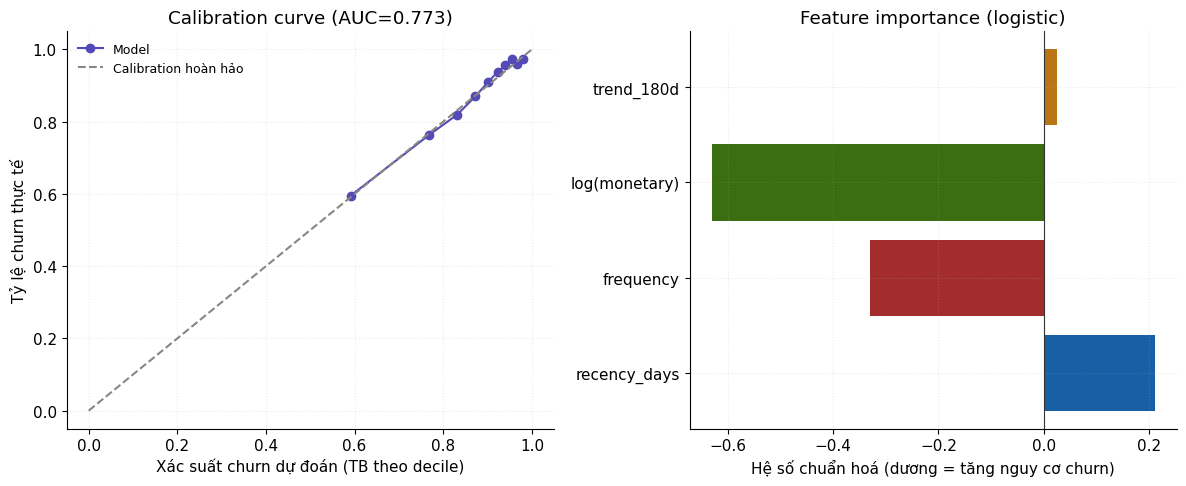

Đã lưu thêm 7 chart (22-28) vào /Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/output/phase3


In [14]:
print("Đang huấn luyện logistic regression thủ công (numpy, time-split validation)...")
CUTOFF = pd.Timestamp("2022-06-30")
hist = non_cancel[non_cancel["order_date"] <= CUTOFF]
future = non_cancel[non_cancel["order_date"] > CUTOFF]

hist_agg = hist.groupby("customer_id").agg(
    last_order=("order_date", "max"), frequency=("order_id", "nunique"), monetary=("payment_value", "sum"))
hist_agg["recency_days"] = (CUTOFF - hist_agg["last_order"]).dt.days

recent180 = hist[hist["order_date"] > CUTOFF - pd.Timedelta(days=180)].groupby("customer_id").size()
prior180 = hist[(hist["order_date"] <= CUTOFF - pd.Timedelta(days=180)) &
                (hist["order_date"] > CUTOFF - pd.Timedelta(days=360))].groupby("customer_id").size()
hist_agg["trend"] = recent180.reindex(hist_agg.index).fillna(0) - prior180.reindex(hist_agg.index).fillna(0)

future_ids = set(future["customer_id"].unique())
hist_agg["churned"] = (~hist_agg.index.isin(future_ids)).astype(int)

print(f"  Tập validate: {len(hist_agg):,} khách có đơn <= {CUTOFF.date()}, "
      f"churn rate thực tế 6 tháng sau = {hist_agg['churned'].mean()*100:.1f}%")

X_raw = np.column_stack([
    hist_agg["recency_days"].values,
    hist_agg["frequency"].values,
    np.log1p(hist_agg["monetary"].values),
    hist_agg["trend"].values,
]).astype(float)
y = hist_agg["churned"].values.astype(float)

rng = np.random.default_rng(42)
idx = rng.permutation(len(y))
n_train = int(len(y) * 0.8)
train_idx, test_idx = idx[:n_train], idx[n_train:]

mu, sigma = X_raw[train_idx].mean(axis=0), X_raw[train_idx].std(axis=0)
sigma[sigma == 0] = 1
X = (X_raw - mu) / sigma
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]


def train_logistic(X, y, lr=0.3, n_iter=3000, l2=0.01):
    n, d = X.shape
    w = np.zeros(d); b = 0.0
    for _ in range(n_iter):
        z = X @ w + b
        p = 1 / (1 + np.exp(-z))
        grad_w = X.T @ (p - y) / n + l2 * w / n
        grad_b = np.mean(p - y)
        w -= lr * grad_w
        b -= lr * grad_b
    return w, b


w, b = train_logistic(X_train, y_train)
p_test = 1 / (1 + np.exp(-(X_test @ w + b)))
pred_test = (p_test >= 0.5).astype(int)

tp = ((pred_test == 1) & (y_test == 1)).sum()
fp = ((pred_test == 1) & (y_test == 0)).sum()
fn = ((pred_test == 0) & (y_test == 1)).sum()
tn = ((pred_test == 0) & (y_test == 0)).sum()
accuracy = (tp + tn) / len(y_test)
precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
f1 = 2 * precision * recall / (precision + recall) if precision and recall else np.nan

ranks = pd.Series(p_test).rank().values
n_pos = y_test.sum(); n_neg = len(y_test) - n_pos
auc = (ranks[y_test == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg) if n_pos > 0 and n_neg > 0 else np.nan

feat_names = ["recency_days", "frequency", "log(monetary)", "trend_180d"]
print("=== 28. Logistic regression (numpy thủ công, time-split cutoff 2022-06-30) ===")
print(f"  Train {len(train_idx):,} / Test {len(test_idx):,} khách")
print(f"  Accuracy={accuracy:.3f} Precision={precision:.3f} Recall={recall:.3f} F1={f1:.3f} AUC={auc:.3f}")
print(f"  Hệ số chuẩn hoá: {dict(zip(feat_names, np.round(w, 3)))}  bias={b:.3f}\n")

calib_df = pd.DataFrame({"p": p_test, "y": y_test})
calib_df["bin"] = pd.qcut(calib_df["p"], 10, duplicates="drop")
calib = calib_df.groupby("bin", observed=True).agg(mean_pred=("p", "mean"), mean_actual=("y", "mean"), n=("y", "size"))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(calib["mean_pred"], calib["mean_actual"], marker="o", color=C_ACCENT, label="Model")
axes[0].plot([0, 1], [0, 1], "--", color=C_GRAY, label="Calibration hoàn hảo")
axes[0].set_xlabel("Xác suất churn dự đoán (TB theo decile)")
axes[0].set_ylabel("Tỷ lệ churn thực tế")
axes[0].set_title(f"Calibration curve (AUC={auc:.3f})")
axes[0].legend(frameon=False, fontsize=9)

axes[1].barh(feat_names, w, color=PALETTE[:4])
axes[1].axvline(0, color="#333", linewidth=0.8)
axes[1].set_xlabel("Hệ số chuẩn hoá (dương = tăng nguy cơ churn)")
axes[1].set_title("Feature importance (logistic)")
fig.tight_layout(); fig.savefig(OUT / "28_logistic_validation.png", dpi=110); plt.show(); plt.close(fig)

print(f"Đã lưu thêm 7 chart (22-28) vào {OUT}")

**Phân tích chart 28 — Logistic regression calibration validation**

1. **Thể hiện gì:** calibration curve của logistic regression dự đoán churn (numpy tự viết, time-split cutoff 2022-06-30) — trục X = xác suất dự đoán, trục Y = tỷ lệ churn thực tế quan sát, đường chéo = calibration lý tưởng.
2. **Insight:** Accuracy 0.877, Precision 0.884, Recall 0.990, **AUC 0.773**. Đường calibration bám khá sát đường chéo → xác suất dự đoán đáng tin cậy để XẾP HẠNG mức độ rủi ro. Hệ số chuẩn hoá: `recency_days +0.211` (Recency cao → tăng nguy cơ, hợp lý), `frequency −0.330`, `log(monetary) −0.630` (mạnh nhất, chi tiêu nhiều → giảm nguy cơ), `trend_180d +0.025` (gần 0, khả năng cộng tuyến với recency).
3. **Lưu ý:** Accuracy 0.877 chỉ nhỉnh hơn baseline "đoán tất cả đều churn" (~0.874, vì churn rate nền đã 87.4% do mất cân bằng nặng) — Accuracy KHÔNG phải chỉ số nên nhìn ở bài toán này, AUC 0.773 mới phản ánh đúng giá trị model (xếp hạng tốt hơn ngẫu nhiên 0.5 đáng kể). Model chỉ tuyến tính, 4 feature đơn giản, viết tay bằng numpy (venv không có sklearn/scipy) — chưa cross-validate nhiều fold, chưa so sánh model khác.


## EXPORT — data trung gian cho DATA_LINEAGE.md (dashboard_rfm_cohort.md mục 1, 2, 4) KHÔNG tính lại số mới — chỉ export đúng các DataFrame đã tính ở trên.

In [15]:
print("\nĐang export data trung gian Phase 3...")

# 1. RFM customer segments (mục 1 dashboard_rfm_cohort.md) — toàn bộ 88,123 khách mẫu RFM
rfm_export = rfm[["customer_id", "last_order", "recency_days", "frequency", "monetary",
                   "R_score", "F_score", "M_score", "segment"]].copy()
rfm_export.to_csv(EXPORT / "rfm_customer_segments.csv", index=False)
print(f"  Đã lưu {EXPORT / 'rfm_customer_segments.csv'} ({len(rfm_export):,} khách)")

# 2. Cohort retention matrix (mục 2 dashboard_rfm_cohort.md) — 126 cohort x offset 0-15 tháng,
#    đúng ma trận đã dùng vẽ 24_cohort_retention_heatmap.png (retention_pct_clip)
cohort_export = retention_pct_clip.copy()
cohort_export.index = cohort_export.index.astype(str)
cohort_export.columns = [f"month_{c}" for c in cohort_export.columns]
cohort_export = cohort_export.reset_index().rename(columns={"index": "cohort_month"})
cohort_export.to_csv(EXPORT / "cohort_retention_matrix.csv", index=False)
print(f"  Đã lưu {EXPORT / 'cohort_retention_matrix.csv'} ({len(cohort_export)} cohort, "
      f"offset 0-{MAX_OFFSET} tháng, % còn hoạt động)")

# 3. Churn risk scores (mục 4 dashboard_rfm_cohort.md) — tier rule-based (toàn mẫu RFM, 88,123 khách)
#    + xác suất logistic (chỉ tính được cho khách có >=1 đơn non-cancelled <= cutoff 2022-06-30,
#    tức nằm trong hist_agg = 87,589 khách; khách còn lại để NaN ở cột p_churn_logistic — không suy
#    diễn/bịa số cho phần không tính được). p_churn_logistic dùng lại đúng X (đã chuẩn hoá bằng
#    mu/sigma của tập train) và w/b đã huấn luyện ở mục 28 — áp dụng cho TOÀN bộ hist_agg (không chỉ
#    tập test) để có điểm số cho mọi khách; cột used_in_logistic_test_set đánh dấu khách nào thuộc
#    17,518 khách trong tập test dùng để tính Accuracy/Precision/Recall/AUC ở mục 28 (tránh hiểu nhầm
#    p_churn_logistic là "đã out-of-sample" cho toàn bộ 87,589 khách).
p_all = 1 / (1 + np.exp(-(X @ w + b)))
logistic_scores = pd.Series(p_all, index=hist_agg.index, name="p_churn_logistic")
is_test_row = pd.Series(False, index=hist_agg.index, name="used_in_logistic_test_set")
is_test_row.iloc[test_idx] = True

churn_export = (risk[["churn_tier"]]
                .join(logistic_scores)
                .join(is_test_row)
                .reset_index())
churn_export.to_csv(EXPORT / "churn_risk_scores.csv", index=False)
print(f"  Đã lưu {EXPORT / 'churn_risk_scores.csv'} ({len(churn_export):,} khách, "
      f"{logistic_scores.notna().sum():,} có p_churn_logistic)")

print(f"\nHoàn tất export 3 file data trung gian vào {EXPORT}")


Đang export data trung gian Phase 3...


  Đã lưu /Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase3_dashboard/data/rfm_customer_segments.csv (88,123 khách)
  Đã lưu /Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase3_dashboard/data/cohort_retention_matrix.csv (126 cohort, offset 0-15 tháng, % còn hoạt động)


  Đã lưu /Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase3_dashboard/data/churn_risk_scores.csv (88,123 khách, 87,589 có p_churn_logistic)

Hoàn tất export 3 file data trung gian vào /Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase3_dashboard/data
